In [1]:
import pandas as pd
import polars as pl
pl.enable_string_cache()
pd.set_option('future.no_silent_downcasting', True)
import glob
import os
import joblib
from funcoes_de_tratamento import *
import matplotlib.pyplot as plt


1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
Instituições com poucos dados: 5
Instituições com variância zero: 0
Instituições com valores negativos: 0
Instituições com outliers: 176
Instituições restantes: 102


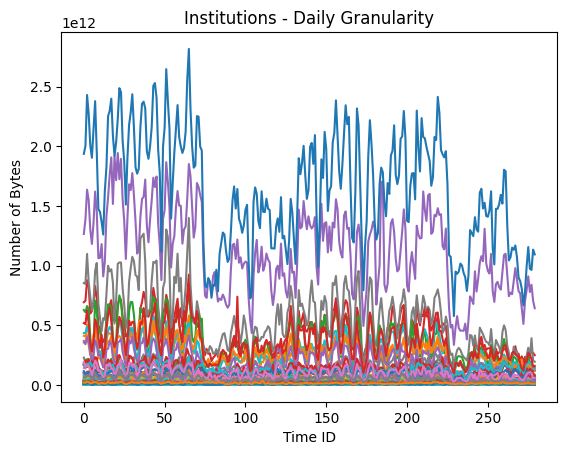

In [2]:
df_day = read_data('../../data/institutions/agg_1_day')
df_hour = read_data('../../data/institutions/agg_1_hour')
df_10min = read_data('../../data/institutions/agg_10_minutes')
#analise dos dados diários
inst = []
p_d = 0
val_null = 0
var_z = 0
val_neg = 0
out = 0
for i in df_day["id_institution"].unique():
    instituicao = df_day[df_day["id_institution"]==i]
    serve = True
    Q1 = instituicao["n_bytes"].quantile(0.20)
    Q3 = instituicao["n_bytes"].quantile(0.80)
    IQR = Q3 - Q1
    L_inferior = Q1 - 1.5*IQR
    L_superior = Q3 + 1.5*IQR

    #verifica se ha instituições com poucos dados e elimina elas se for o caso
    if instituicao.shape[0] < 260:
        #print(f"{i} tem poucos dados")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        p_d += 1

        '''
    #verifica se ha instituições com valores nulos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"].isnull()].shape[0]>0:
        #print(f"{i} tem valores nulos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        val_null += 1
        '''
        
    #verifica se ha instituições com variância zero e elimina elas se for o caso
    elif instituicao["n_bytes"].var() == 0:
        #print(f"{i} tem variância zero")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        var_z += 1

    #verifica se ha instituições com valores negativos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"]<0].shape[0]>0:
        #print(f"{i} tem valores negativos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        val_neg += 1

    #verifica se ha instituições com outliers (valores muito altos) e elimina elas se for o caso
    elif instituicao[(instituicao["n_bytes"] > L_superior) | (instituicao["n_bytes"] < L_inferior)].shape[0]>0:
        serve = False
        out += 1


    if serve:
        inst.append(i)

print(f"Instituições com poucos dados: {p_d}")
print(f"Instituições com variância zero: {var_z}")
print(f"Instituições com valores negativos: {val_neg}")
print(f"Instituições com outliers: {out}")
print(f"Instituições restantes: {len(inst)}")
for i in inst:
    instituicao = df_day[df_day["id_institution"]==i]
    
    plt.plot(instituicao["id_time"], instituicao["n_bytes"], label=i)
plt.title(f"Institutions - Daily Granularity")
plt.xlabel("Time ID")
plt.ylabel("Number of Bytes")
plt.show()

df_day = df_day[df_day["id_institution"].isin(inst)]
df_hour = df_hour[df_hour["id_institution"].isin(inst)]
df_10min = df_10min[df_10min["id_institution"].isin(inst)]


inst = [int(c) for c in inst]
joblib.dump(inst, "inst.joblib")

  
print()

In [3]:
time_day = pd.read_csv('../../data/times/times_1_day.csv')
time_hour = pd.read_csv('../../data/times/times_1_hour.csv')
time_minute = pd.read_csv('../../data/times/times_10_minutes.csv')

df_day["id_time"] = df_day["id_time"].astype(int)
df_hour["id_time"] = df_hour["id_time"].astype(int)
df_10min["id_time"] = df_10min["id_time"].astype(int)

df_day = df_day.merge(time_day, on="id_time", how="left")
df_day["time"] = pd.to_datetime(df_day["time"])
df_day["time"] = pd.to_datetime(pd.DataFrame(
        {
            "year": df_day["time"].dt.year.astype("int"),
            "month": df_day["time"].dt.month.astype("int"),
            "day": df_day["time"].dt.day.astype("int"),
            "hour": df_day["time"].dt.hour.astype("int"),
            "minute": (round(df_day["time"].dt.minute.astype("int") /10))*10,
            "second": 0

        }
    )
)
df_day["id_institution"] = df_day["id_institution"].astype("int")
df_day = df_day.sort_values(by = ["time", "id_institution"])
df_day.drop(columns=["id_time"], inplace=True)

df_hour = df_hour.merge(time_hour, on="id_time", how="left")
df_hour["time"] = pd.to_datetime(df_hour["time"])
df_hour["time"] = pd.to_datetime(pd.DataFrame(
        {
            "year": df_hour["time"].dt.year.astype("int"),
            "month": df_hour["time"].dt.month.astype("int"),
            "day": df_hour["time"].dt.day.astype("int"),
            "hour": df_hour["time"].dt.hour.astype("int"),
            "minute": (round(df_hour["time"].dt.minute.astype("int") /10))*10,
            "second": 0

        }
    )
)
df_hour["id_institution"] = df_hour["id_institution"].astype("int")
df_hour = df_hour.sort_values(by = ["time", "id_institution"])
df_hour.drop(columns=["id_time"], inplace=True)

df_10min = df_10min.merge(time_minute, on="id_time", how="left")
df_10min["time"] = pd.to_datetime(df_10min["time"], utc = True)
df_10min["time"] = pd.to_datetime(pd.DataFrame(
        {
            "year": df_10min["time"].dt.year.astype("int"),
            "month": df_10min["time"].dt.month.astype("int"),
            "day": df_10min["time"].dt.day.astype("int"),
            "hour": df_10min["time"].dt.hour.astype("int"),
            "minute": (round(df_10min["time"].dt.minute.astype("int") /10))*10,
            "second": 0

        }
    )
)
df_hour["id_institution"] = df_hour["id_institution"].astype("int")
df_10min["id_institution"] = df_10min["id_institution"].astype("int")
df_10min = df_10min.sort_values(by = ["time", "id_institution"])
df_10min.drop(columns=["id_time"], inplace=True)


In [4]:
df_day["id_institution"].value_counts()

id_institution
0      280
3      280
4      280
5      280
8      280
      ... 
244    280
249    280
254    280
265    280
284    280
Name: count, Length: 102, dtype: int64

In [5]:
df_hour["id_institution"].value_counts()

id_institution
0      6717
3      6717
4      6717
5      6717
9      6717
       ... 
239    6705
8      6703
72     6699
265    6654
243    6534
Name: count, Length: 102, dtype: int64

In [6]:
df_10min["id_institution"].value_counts()

id_institution
0      40298
3      40298
10     40298
9      40298
23     40298
       ...  
203    21934
265    10205
72      8281
222     6603
151     3402
Name: count, Length: 102, dtype: int64

In [7]:
series_day = pd.Series( pd.date_range(start = df_day["time"].min(), end = df_day["time"].max(), freq = "D"), name = "time")
display(series_day)

series_hour = pd.Series(pd.date_range(start=df_hour["time"].min(), end=df_hour["time"].max(), freq='h'), name="time")
display(series_hour)

series_10min = pd.Series(pd.date_range(start=df_10min["time"].min(), end=df_10min["time"].max(), freq='10min'), name="time")
display(series_10min)


0     2023-10-09
1     2023-10-10
2     2023-10-11
3     2023-10-12
4     2023-10-13
         ...    
275   2024-07-10
276   2024-07-11
277   2024-07-12
278   2024-07-13
279   2024-07-14
Name: time, Length: 280, dtype: datetime64[ns]

0      2023-10-09 00:00:00
1      2023-10-09 01:00:00
2      2023-10-09 02:00:00
3      2023-10-09 03:00:00
4      2023-10-09 04:00:00
               ...        
6713   2024-07-14 17:00:00
6714   2024-07-14 18:00:00
6715   2024-07-14 19:00:00
6716   2024-07-14 20:00:00
6717   2024-07-14 21:00:00
Name: time, Length: 6718, dtype: datetime64[ns]

0       2023-10-09 00:00:00
1       2023-10-09 00:10:00
2       2023-10-09 00:20:00
3       2023-10-09 00:30:00
4       2023-10-09 00:40:00
                ...        
40303   2024-07-14 21:10:00
40304   2024-07-14 21:20:00
40305   2024-07-14 21:30:00
40306   2024-07-14 21:40:00
40307   2024-07-14 21:50:00
Name: time, Length: 40308, dtype: datetime64[ns]

In [8]:
dfs = []
for id in inst:
    df_d = df_day[df_day["id_institution"] ==  id].copy()
    df_d = df_d.merge(series_day, on = "time", how = "right")
    df_d["id_institution"] = df_d["id_institution"].fillna(id).astype("int")
    df_d["n_bytes"] = df_d["n_bytes"].bfill().ffill()
    dfs.append(df_d)

df_day = pd.concat(dfs)


dfs = []
for id in inst:
    df_h = df_hour[df_hour["id_institution"] ==  id].copy()
    df_h = df_h.merge(series_hour, on = "time", how = "right")
    
    df_h["id_institution"] =df_h["id_institution"].fillna(id).astype("int")
    dfs.append(df_h)

df_hour = pd.concat(dfs)

dfs = []
for id in inst:
    df_m = df_10min[df_10min["id_institution"] ==  id].copy()
    df_m = df_m.merge(series_10min, on = "time", how = "right")
    df_m["id_institution"] = df_m["id_institution"].fillna(id).astype("int")
    dfs.append(df_m)

df_10min = pd.concat(dfs)

In [65]:
display(df_day)
display(df_hour)
display(df_10min)

,n_bytes,id_institution,time
0,104254214117,137,2023-10-09
1,77598243579,137,2023-10-10
2,107828916252,137,2023-10-11
3,75404450175,137,2023-10-12
4,73054357548,137,2023-10-13
...,...,...,...
275,20056212285,83,2024-07-10
276,9558339042,83,2024-07-11
277,11933568726,83,2024-07-12
278,8496556858,83,2024-07-13


,n_bytes,id_institution,time
0,2.979420e+09,137,2023-10-09 00:00:00
1,1.054940e+09,137,2023-10-09 01:00:00
2,1.699339e+10,137,2023-10-09 02:00:00
3,4.096599e+09,137,2023-10-09 03:00:00
4,2.537641e+09,137,2023-10-09 04:00:00
...,...,...,...
6713,8.969877e+08,83,2024-07-14 17:00:00
6714,7.066403e+08,83,2024-07-14 18:00:00
6715,1.275217e+07,83,2024-07-14 19:00:00
6716,7.482055e+08,83,2024-07-14 20:00:00


,n_bytes,id_institution,time
0,796727424,137,2023-10-09 00:00:00
1,35517598,137,2023-10-09 00:10:00
2,22809023,137,2023-10-09 00:20:00
3,46543563,137,2023-10-09 00:30:00
4,2019183184,137,2023-10-09 00:40:00
...,...,...,...
40303,3511381,83,2024-07-14 21:10:00
40304,1774880,83,2024-07-14 21:20:00
40305,668945468,83,2024-07-14 21:30:00
40306,53912021,83,2024-07-14 21:40:00


In [9]:
df_day["time_d"] = df_day["time"].dt.date
df_hour["time_d"] = df_hour["time"].dt.date
df_hour["time_h"] = pd.to_datetime(pd.DataFrame(
        {
            "year": df_hour["time"].dt.year.astype("int"),
            "month": df_hour["time"].dt.month.astype("int"),
            "day": df_hour["time"].dt.day.astype("int"),
            "hour": df_hour["time"].dt.hour.astype("int"),
            "minute": 0,
            "second": 0

        }
    )
)

df_10min["time_h"] = pd.to_datetime(pd.DataFrame(
        {
            "year": df_10min["time"].dt.year.astype("int"),
            "month": df_10min["time"].dt.month.astype("int"),
            "day": df_10min["time"].dt.day.astype("int"),
            "hour": df_10min["time"].dt.hour.astype("int"),
            "minute": 0,
            "second": 0

        }
    )
)

In [10]:
display(df_day)
display(df_hour)
display(df_10min)

,n_bytes,id_institution,time,time_d
0,104254214117,137,2023-10-09,2023-10-09
1,77598243579,137,2023-10-10,2023-10-10
2,107828916252,137,2023-10-11,2023-10-11
3,75404450175,137,2023-10-12,2023-10-12
4,73054357548,137,2023-10-13,2023-10-13
...,...,...,...,...
275,20056212285,83,2024-07-10,2024-07-10
276,9558339042,83,2024-07-11,2024-07-11
277,11933568726,83,2024-07-12,2024-07-12
278,8496556858,83,2024-07-13,2024-07-13


,n_bytes,id_institution,time,time_d,time_h
0,2.979420e+09,137,2023-10-09 00:00:00,2023-10-09,2023-10-09 00:00:00
1,1.054940e+09,137,2023-10-09 01:00:00,2023-10-09,2023-10-09 01:00:00
2,1.699339e+10,137,2023-10-09 02:00:00,2023-10-09,2023-10-09 02:00:00
3,4.096599e+09,137,2023-10-09 03:00:00,2023-10-09,2023-10-09 03:00:00
4,2.537641e+09,137,2023-10-09 04:00:00,2023-10-09,2023-10-09 04:00:00
...,...,...,...,...,...
6713,8.969877e+08,83,2024-07-14 17:00:00,2024-07-14,2024-07-14 17:00:00
6714,7.066403e+08,83,2024-07-14 18:00:00,2024-07-14,2024-07-14 18:00:00
6715,1.275217e+07,83,2024-07-14 19:00:00,2024-07-14,2024-07-14 19:00:00
6716,7.482055e+08,83,2024-07-14 20:00:00,2024-07-14,2024-07-14 20:00:00


,n_bytes,id_institution,time,time_h
0,796727424,137,2023-10-09 00:00:00,2023-10-09 00:00:00
1,35517598,137,2023-10-09 00:10:00,2023-10-09 00:00:00
2,22809023,137,2023-10-09 00:20:00,2023-10-09 00:00:00
3,46543563,137,2023-10-09 00:30:00,2023-10-09 00:00:00
4,2019183184,137,2023-10-09 00:40:00,2023-10-09 00:00:00
...,...,...,...,...
40303,3511381,83,2024-07-14 21:10:00,2024-07-14 21:00:00
40304,1774880,83,2024-07-14 21:20:00,2024-07-14 21:00:00
40305,668945468,83,2024-07-14 21:30:00,2024-07-14 21:00:00
40306,53912021,83,2024-07-14 21:40:00,2024-07-14 21:00:00


In [21]:
df_hour = df_hour_.copy()
df_10min = df_10min_.copy()

In [22]:
df_hour = df_hour.merge(df_day, on = ["id_institution", "time_d"], how = "left", suffixes=("_hour", "_day"))
df_hour["n_bytes_hour"] = df_hour["n_bytes_hour"].fillna(round(df_hour["n_bytes_day"] / 24))
df_hour.rename(columns={"time_hour": "time", "n_bytes_hour": "n_bytes"},inplace= True)
df_hour.drop(columns= ["time_day", "n_bytes_day"],inplace= True)
df_hour

,n_bytes,id_institution,time,time_d,time_h
0,2.979420e+09,137,2023-10-09 00:00:00,2023-10-09,2023-10-09 00:00:00
1,1.054940e+09,137,2023-10-09 01:00:00,2023-10-09,2023-10-09 01:00:00
2,1.699339e+10,137,2023-10-09 02:00:00,2023-10-09,2023-10-09 02:00:00
3,4.096599e+09,137,2023-10-09 03:00:00,2023-10-09,2023-10-09 03:00:00
4,2.537641e+09,137,2023-10-09 04:00:00,2023-10-09,2023-10-09 04:00:00
...,...,...,...,...,...
685231,8.969877e+08,83,2024-07-14 17:00:00,2024-07-14,2024-07-14 17:00:00
685232,7.066403e+08,83,2024-07-14 18:00:00,2024-07-14,2024-07-14 18:00:00
685233,1.275217e+07,83,2024-07-14 19:00:00,2024-07-14,2024-07-14 19:00:00
685234,7.482055e+08,83,2024-07-14 20:00:00,2024-07-14,2024-07-14 20:00:00


In [23]:
df_10min = df_10min.merge(df_hour, on = ["id_institution", "time_h"], how = "left", suffixes=("_10min", "_hour"))
df_10min["n_bytes_10min"] = df_10min["n_bytes_10min"].fillna(round(df_10min["n_bytes_hour"] / 6))
df_10min.rename(columns={"time_10min": "time", "n_bytes_10min": "n_bytes"},inplace= True)
df_10min

,n_bytes,id_institution,time,time_h,n_bytes_hour,time_hour,time_d
0,796727424,137,2023-10-09 00:00:00,2023-10-09 00:00:00,2.979420e+09,2023-10-09 00:00:00,2023-10-09
1,35517598,137,2023-10-09 00:10:00,2023-10-09 00:00:00,2.979420e+09,2023-10-09 00:00:00,2023-10-09
2,22809023,137,2023-10-09 00:20:00,2023-10-09 00:00:00,2.979420e+09,2023-10-09 00:00:00,2023-10-09
3,46543563,137,2023-10-09 00:30:00,2023-10-09 00:00:00,2.979420e+09,2023-10-09 00:00:00,2023-10-09
4,2019183184,137,2023-10-09 00:40:00,2023-10-09 00:00:00,2.979420e+09,2023-10-09 00:00:00,2023-10-09
...,...,...,...,...,...,...,...
4111411,3511381,83,2024-07-14 21:10:00,2024-07-14 21:00:00,1.410801e+09,2024-07-14 21:00:00,2024-07-14
4111412,1774880,83,2024-07-14 21:20:00,2024-07-14 21:00:00,1.410801e+09,2024-07-14 21:00:00,2024-07-14
4111413,668945468,83,2024-07-14 21:30:00,2024-07-14 21:00:00,1.410801e+09,2024-07-14 21:00:00,2024-07-14
4111414,53912021,83,2024-07-14 21:40:00,2024-07-14 21:00:00,1.410801e+09,2024-07-14 21:00:00,2024-07-14


In [24]:
atributos = ["time", "id_institution", "n_bytes"]
df_day = df_day[atributos].drop_duplicates()
df_hour = df_hour[atributos].drop_duplicates()
df_10min = df_10min[atributos].drop_duplicates()

In [25]:
display(df_day)
display(df_hour)
display(df_10min)

,time,id_institution,n_bytes
0,2023-10-09,137,104254214117
1,2023-10-10,137,77598243579
2,2023-10-11,137,107828916252
3,2023-10-12,137,75404450175
4,2023-10-13,137,73054357548
...,...,...,...
275,2024-07-10,83,20056212285
276,2024-07-11,83,9558339042
277,2024-07-12,83,11933568726
278,2024-07-13,83,8496556858


,time,id_institution,n_bytes
0,2023-10-09 00:00:00,137,2.979420e+09
1,2023-10-09 01:00:00,137,1.054940e+09
2,2023-10-09 02:00:00,137,1.699339e+10
3,2023-10-09 03:00:00,137,4.096599e+09
4,2023-10-09 04:00:00,137,2.537641e+09
...,...,...,...
685231,2024-07-14 17:00:00,83,8.969877e+08
685232,2024-07-14 18:00:00,83,7.066403e+08
685233,2024-07-14 19:00:00,83,1.275217e+07
685234,2024-07-14 20:00:00,83,7.482055e+08


,time,id_institution,n_bytes
0,2023-10-09 00:00:00,137,796727424
1,2023-10-09 00:10:00,137,35517598
2,2023-10-09 00:20:00,137,22809023
3,2023-10-09 00:30:00,137,46543563
4,2023-10-09 00:40:00,137,2019183184
...,...,...,...
4111411,2024-07-14 21:10:00,83,3511381
4111412,2024-07-14 21:20:00,83,1774880
4111413,2024-07-14 21:30:00,83,668945468
4111414,2024-07-14 21:40:00,83,53912021


In [26]:
display(df_day[df_day["n_bytes"].isna()])
display(df_hour[df_hour["n_bytes"].isna()])
display(df_10min[df_10min["n_bytes"].isna()])

,time,id_institution,n_bytes


,time,id_institution,n_bytes


,time,id_institution,n_bytes


In [27]:
df_day.to_parquet("../../data/tratados/df_day.parquet")
df_hour.to_parquet("../../data/tratados/df_hour.parquet")
df_10min.to_parquet("../../data/tratados/df_10min.parquet")